# Georgia Drinking Water Contamination and Cancer Incidence

## Research Question

Is exposure to contaminated drinking water associated with cancer incidence across Georgia counties?

## Data Sources

### Cancer Incidence Data

- **Source:** Georgia Department of Public Health
- **Report:** *Age-Adjusted Cancer Incidence Rates for the State of Georgia, 2019–2023*
- **Geographic level:** Georgia counties
- **Years represented:** 2019–2023
- **Data used:** All-sites cancer cases and age-adjusted incidence rates, including total, sex-specific, and selected race/sex-specific measures
- **Original format:** PDF
- **Date downloaded:** 30 August 2026

### Drinking Water Data

- **Source:** U.S. Environmental Protection Agency (EPA), Enforcement and Compliance History Online (ECHO)
- **Database:** Safe Drinking Water Act (SDWA) Dataset
- **Source system:** Safe Drinking Water Information System (SDWIS)
- **Geographic level:** Public water systems, later aggregated to Georgia counties
- **Exposure period used:** 2016–2023
- **Original format:** ZIP file containing CSV files
- **Date downloaded:** 30 August 2026
- **Files used:** `SDWA_VIOLATIONS_ENFORCEMENT.csv`, `SDWA_PUB_WATER_SYSTEMS.csv`, and `SDWA_GEOGRAPHIC_AREAS.csv`

## Public Health Significance

Contaminated drinking water can be a long-term public health concern and may be associated with increased cancer risk depending on the contaminant and length of exposure. This analysis examines whether Georgia counties with more health-based drinking water violations also have higher cancer incidence rates. Since the analysis is at the county level, it cannot determine individual exposure or establish causation, but it can identify patterns that may be useful for further research.

## Preliminary Analytical Scope

This analysis focuses on cleaning and combining the cancer and drinking water data at the county level and examining the relationship between health-based drinking water violations and overall cancer incidence.

The cancer dataset also includes sex-specific and selected race/sex-specific incidence rates. These variables were included because differences between demographic groups may be important when examining environmental health outcomes. The overall cancer incidence rate was used for the main analysis first, while the subgroup variables were kept for possible stratified analysis depending on the initial results.

In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Download the source data files
!gdown 1YpIDfIe3JdCYb9Te-BJKo2GQndwmH6pO -O "Georgia Cancer Incidences.pdf"
!gdown 1EMyFSD0zHGa40wxbwXBgiomOcSFPPh0B -O "SDWA_latest_downloads.zip"

Downloading...
From: https://drive.google.com/uc?id=1YpIDfIe3JdCYb9Te-BJKo2GQndwmH6pO
To: /content/Georgia Cancer Incidences.pdf
100% 926k/926k [00:00<00:00, 123MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1EMyFSD0zHGa40wxbwXBgiomOcSFPPh0B
From (redirected): https://drive.google.com/uc?id=1EMyFSD0zHGa40wxbwXBgiomOcSFPPh0B&confirm=t&uuid=9d2ce4d1-7ec4-4225-9529-6f0b67929c9d
To: /content/SDWA_latest_downloads.zip
100% 424M/424M [00:02<00:00, 203MB/s]


## Loading the Cancer Dataset

The Georgia cancer incidence data were provided as a PDF report from the Georgia Department of Public Health. Because the source is a PDF rather than a CSV or Excel file, the `pdfplumber` Python package is used to extract the county-level table for analysis.

In [ ]:
# Install pdfplumber to extract data from the PDF
!pip install -q pdfplumber

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 1.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 20.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 19.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 27.4 MB/s eta 0:00:00


In [ ]:
# Import pdfplumber and identify the cancer data file
import pdfplumber

pdf_file = "Georgia Cancer Incidences.pdf"

# Check the number of pages in the report
with pdfplumber.open(pdf_file) as pdf:
    print("Number of pages:", len(pdf.pages))

Number of pages: 24


In [ ]:
with pdfplumber.open(pdf_file) as pdf:
    for i, page in enumerate(pdf.pages):
        text = page.extract_text() or ""
        if "County" in text:
            print(f"Page {i + 1}")

Page 5
Page 6
Page 7
Page 8
Page 9
Page 10
Page 11
Page 12
Page 13
Page 14
Page 15
Page 16
Page 17
Page 18
Page 19
Page 20
Page 21
Page 22
Page 23
Page 24


### Data Extraction

The Georgia Department of Public Health cancer report contains county-level cancer incidence data. The "ALL SITES" table was selected as the primary cancer outcome because it provides age-adjusted cancer incidence rates for all cancer sites combined.

The table also includes cancer incidence information by sex and selected racial/ethnic groups. These variables were included so that demographic differences could be considered during the analysis.

In [ ]:
# Extract the county-level ALL SITES table from pages 5–8
all_sites_lines = []

with pdfplumber.open(pdf_file) as pdf:
    for page_num in range(4, 8):  # PDF pages 5–8
        page_text = pdf.pages[page_num].extract_text()
        all_sites_lines.extend(page_text.splitlines())

### Verification of Extracted Pages

The extracted text was checked to confirm that the complete county-level "ALL SITES" table was captured before cleaning the data.

In [ ]:
# Verify the extracted text
print("Total extracted lines:", len(all_sites_lines))

# Confirm that the final county was extracted
worth_lines = [line for line in all_sites_lines if line.startswith("Worth ")]
print("Final county found:", worth_lines[-1] if worth_lines else "Not found")

Total extracted lines: 193
Final county found: Worth 685 469.0 387 564.0 101 708.1 280 537.3 298 397.5 69 351.2 225 418.2


### Isolating County Records

The extracted text includes county records along with repeated headers, statewide totals, and footnotes. The next step keeps only the county-level rows and removes the non-data lines.

Because some county names contain more than one word, the rows cannot be split at the first space. Instead, the first numeric value in each line is used to identify where the county name ends and the cancer data begin.

In [ ]:
# Identify valid county-level records
county_rows = []

for line in all_sites_lines:
    parts = line.split()

    # Find where the county name ends and the numeric data begin
    first_numeric_index = next(
        (i for i, value in enumerate(parts) if value.isdigit() or value == "<5"),
        None
    )

    if first_numeric_index is not None:
        county = " ".join(parts[:first_numeric_index])
        data_values = parts[first_numeric_index:]

        # Valid county rows contain 14 cancer data values
        if county != "Georgia" and len(data_values) == 14:
            county_rows.append(line)

# Verify that all 159 Georgia counties were captured
print("Number of county rows:", len(county_rows))
print("First county:", county_rows[0].split()[0])
print("Last county:", county_rows[-1].split()[0])

Number of county rows: 159
First county: Appling
Last county: Worth


### Creating the Cancer DataFrame

After identifying the 159 valid county records, the extracted text is converted into a pandas DataFrame. Each record is separated into the county name and 14 cancer-related values representing case counts and age-adjusted incidence rates for the total population and selected sex/race groups.

In [ ]:
# Define column names for the cancer dataset
cancer_columns = [
    "county",
    "total_cases",
    "total_rate",
    "male_cases",
    "male_rate",
    "black_male_cases",
    "black_male_rate",
    "white_male_cases",
    "white_male_rate",
    "female_cases",
    "female_rate",
    "black_female_cases",
    "black_female_rate",
    "white_female_cases",
    "white_female_rate"
]

# Parse the county records
parsed_rows = []

for line in county_rows:
    parts = line.split()

    first_numeric_index = next(
        (i for i, value in enumerate(parts) if value.isdigit() or value == "<5"),
        None
    )

    county = " ".join(parts[:first_numeric_index])
    data_values = parts[first_numeric_index:]

    parsed_rows.append([county] + data_values)

# Create the cancer DataFrame
cancer_df = pd.DataFrame(parsed_rows, columns=cancer_columns)

cancer_df.head()

,county,total_cases,total_rate,male_cases,male_rate,black_male_cases,black_male_rate,white_male_cases,white_male_rate,female_cases,female_rate,black_female_cases,black_female_rate,white_female_cases,white_female_rate
0,Appling,601,498.6,316,539.6,53,519.6,250,559.2,285,469.8,37,353.6,237,510.4
1,Atkinson,221,462.9,120,524.3,25,528.8,81,551.6,101,412.9,19,352.1,75,464.7
2,Bacon,336,486.4,185,568.8,25,698.0,154,561.8,151,425.6,24,551.0,120,404.4
3,Baker,108,435.8,63,474.5,29,471.6,34,489.9,45,396.3,17,339.4,27,485.7
4,Baldwin,1372,505.3,758,550.6,284,589.9,449,539.5,614,469.8,236,460.9,366,491.8


### Basic Dataset Information

The cancer dataset is checked to confirm the number of observations and variables, review the column names, and inspect the data types before cleaning.

In [ ]:
# Review the dataset structure
print("Dataset shape:", cancer_df.shape)

print("\nColumn names:")
print(cancer_df.columns.tolist())

print("\nData types:")
print(cancer_df.dtypes)

Dataset shape: (159, 15)

Column names:
['county', 'total_cases', 'total_rate', 'male_cases', 'male_rate', 'black_male_cases', 'black_male_rate', 'white_male_cases', 'white_male_rate', 'female_cases', 'female_rate', 'black_female_cases', 'black_female_rate', 'white_female_cases', 'white_female_rate']

Data types:
county                object
total_cases           object
total_rate            object
male_cases            object
male_rate             object
black_male_cases      object
black_male_rate       object
white_male_cases      object
white_male_rate       object
female_cases          object
female_rate           object
black_female_cases    object
black_female_rate     object
white_female_cases    object
white_female_rate     object
dtype: object


## Data Cleaning

### Missing and Suppressed Values

The Georgia cancer dataset contains special symbols that represent unavailable or suppressed values. According to the Georgia Department of Public Health report, a rate marked with `~` was not calculated when the corresponding case count was less than 16, while `***` indicates that data were suppressed for confidentiality.

Values reported as `<5` also cannot be treated as exact numeric case counts because the precise value is unknown. For numeric analysis, `~`, `***`, and `<5` were converted to missing values (`NaN`) rather than estimated or replaced with arbitrary numbers. This avoids introducing values that were not reported by the original data source.

In [ ]:
# Count special values before converting them to NaN
special_values = ["~", "***", "<5"]

for value in special_values:
    count = (cancer_df == value).sum().sum()
    print(f"{value}: {count}")

~: 39
***: 0
<5: 22


#### Missing Value Assessment

Before converting the cancer variables to numeric format, special values were counted across the dataset. There were 39 values marked with `~`, indicating that an incidence rate was not calculated because the corresponding case count was less than 16. There were also 22 case-count values reported as `<5`, meaning the exact number of cases was not provided. No values marked with `***` for confidentiality suppression were identified in the extracted "ALL SITES" county data.

For numeric analysis, these non-numeric values were represented as `NaN` rather than zero because the symbols do not indicate an absence of cancer cases.

In [ ]:
# Replace special values with NaN
cancer_df = cancer_df.replace({
    "~": np.nan,
    "***": np.nan,
    "<5": np.nan
})

# Verify that the special values were removed
for value in special_values:
    print(f"{value}: {(cancer_df == value).sum().sum()}")

~: 0
***: 0
<5: 0


In [ ]:
# Convert cancer variables to numeric values
numeric_columns = cancer_df.columns.drop("county")

for column in numeric_columns:
    cancer_df[column] = pd.to_numeric(cancer_df[column], errors="coerce")

# Verify the updated data types
cancer_df.dtypes

,0
county,object
total_cases,int64
total_rate,float64
male_cases,int64
male_rate,float64
black_male_cases,float64
black_male_rate,float64
white_male_cases,int64
white_male_rate,float64
female_cases,int64


### Verification of Missing Values

After converting the special values to `NaN` and the cancer measures to numeric data types, missing values were checked by variable. This verifies where suppressed or unreported values occur and identifies any additional values that became missing during numeric conversion.

In [ ]:
# Count missing values in each column after numeric conversion
missing_counts = cancer_df.isna().sum()

# Display only columns that contain missing values
missing_counts[missing_counts > 0]

,0
black_male_cases,10
black_male_rate,17
black_female_cases,12
black_female_rate,22
white_female_rate,1


In [ ]:
## Check for unexpected non-numeric values in the extracted cancer data
known_special_values = {"~", "***", "<5"}
unexpected_values = []

for line in county_rows:
    parts = line.split()

    first_numeric_index = next(
        (i for i, value in enumerate(parts) if value.isdigit() or value == "<5"),
        None
    )

    for value in parts[first_numeric_index:]:
        try:
            float(value)
        except ValueError:
            if value not in known_special_values:
                unexpected_values.append((line, value))

unexpected_values

[('Franklin 889 557.0 465 611.1 58 ##### 389 575.0 424 520.5 47 833.0 360 501.9',
  '#####')]

One additional non-numeric value (`#####`) was identified in the Non-Hispanic Black male incidence rate for Franklin County. Because this symbol was not defined in the report's footnotes and could not be interpreted as a valid numeric rate, it was treated as a missing value (`NaN`).

In [ ]:
# Calculate the total number of missing values after cleaning
total_missing = cancer_df.isna().sum().sum()

print("Total missing values:", total_missing)

Total missing values: 62


### Outliers and Implausible Values

Numeric variables were reviewed for unusually high, low, or implausible values after conversion. Some variation was expected because cancer incidence can differ across counties and demographic groups, so extreme values were not automatically treated as errors. Variable ranges were reviewed to identify values that could indicate extraction or data quality problems.

In [ ]:
# Display summary statistics for all numeric cancer variables
cancer_df.describe().T

,count,mean,std,min,25%,50%,75%,max
total_cases,159.0,1840.402516,3527.843850,62.0,339.000,756.0,1598.500,26339.0
total_rate,159.0,476.125157,41.743888,333.4,452.200,477.3,503.550,584.0
male_cases,159.0,952.081761,1783.724825,40.0,187.000,407.0,824.000,13397.0
male_rate,159.0,533.311950,55.430624,336.8,501.950,533.2,572.650,653.6
black_male_cases,149.0,277.630872,714.904117,5.0,35.000,85.0,171.000,5853.0
black_male_rate,142.0,566.538028,105.597196,309.1,508.250,559.9,636.150,994.8
white_male_cases,159.0,626.641509,1008.087118,17.0,124.500,299.0,669.000,6786.0
white_male_rate,159.0,535.000629,62.018223,370.2,498.450,537.3,580.050,755.5
female_cases,159.0,888.025157,1744.148035,22.0,153.500,354.0,766.000,12931.0
female_rate,159.0,436.256604,47.306438,287.6,411.850,439.7,465.100,649.5


#### Outlier Assessment

The summary statistics were reviewed to check for values that seemed unusually high, low, or unrealistic. Some of the race- and sex-specific incidence rates had a wider range than the overall cancer rate. However, these values were not removed because differences between counties and smaller demographic groups may result in more variation in the rates.

The numeric variables were also checked for negative values, and none were found. Since there were no clearly impossible values, no observations were removed as outliers.

In [ ]:
# Check for logically impossible negative values
negative_values = (cancer_df[numeric_columns] < 0).sum()

# Display any variables containing negative values
negative_values[negative_values > 0]

,0


## EPA Safe Drinking Water Data

Drinking water data were obtained from the U.S. Environmental Protection Agency (EPA) Safe Drinking Water Act (SDWA) dataset. The data were used to identify health-based drinking water violations affecting public water systems serving Georgia counties.

The EPA files were first inspected to identify the variables needed to measure the occurrence and timing of drinking water violations and to link public water systems to counties.

In [ ]:
# Verify that the required data files are available in the Colab session
import os

os.listdir()

['.config',
 'Georgia Cancer Incidences.pdf',
 'SDWA_latest_downloads.zip',
 'sample_data']

In [ ]:
import zipfile

epa_zip = "SDWA_latest_downloads.zip"

# List the files included in the EPA ZIP archive
with zipfile.ZipFile(epa_zip, "r") as zip_ref:
    epa_files = zip_ref.namelist()

for file in epa_files:
    print(file)

SDWA_EVENTS_MILESTONES.csv
SDWA_FACILITIES.csv
SDWA_GEOGRAPHIC_AREAS.csv
SDWA_LCR_SAMPLES.csv
SDWA_PUB_WATER_SYSTEMS.csv
SDWA_PN_VIOLATION_ASSOC.csv
SDWA_REF_ANSI_AREAS.csv
SDWA_REF_CODE_VALUES.csv
SDWA_SERVICE_AREAS.csv
SDWA_SITE_VISITS.csv
SDWA_VIOLATIONS_ENFORCEMENT.csv


In [ ]:
# EPA files considered for the drinking water analysis
files_to_check = [
    "SDWA_VIOLATIONS_ENFORCEMENT.csv",
    "SDWA_PUB_WATER_SYSTEMS.csv",
    "SDWA_GEOGRAPHIC_AREAS.csv",
    "SDWA_REF_CODE_VALUES.csv"
]

# Inspect the structure of each file using a small sample
with zipfile.ZipFile(epa_zip, "r") as zip_ref:
    for file_name in files_to_check:
        print(f"\n--- {file_name} ---")

        with zip_ref.open(file_name) as file:
            sample = pd.read_csv(file, nrows=5, low_memory=False)

        print("Shape of sample:", sample.shape)

        print("\nColumns:")
        print(sample.columns.tolist())

        print("\nSample rows:")
        display(sample)


--- SDWA_VIOLATIONS_ENFORCEMENT.csv ---
Shape of sample: (5, 38)

Columns:
['SUBMISSIONYEARQUARTER', 'PWSID', 'VIOLATION_ID', 'FACILITY_ID', 'COMPL_PER_BEGIN_DATE', 'COMPL_PER_END_DATE', 'NON_COMPL_PER_BEGIN_DATE', 'NON_COMPL_PER_END_DATE', 'PWS_DEACTIVATION_DATE', 'VIOLATION_CODE', 'VIOLATION_CATEGORY_CODE', 'IS_HEALTH_BASED_IND', 'CONTAMINANT_CODE', 'VIOL_MEASURE', 'UNIT_OF_MEASURE', 'FEDERAL_MCL', 'STATE_MCL', 'IS_MAJOR_VIOL_IND', 'SEVERITY_IND_CNT', 'CALCULATED_RTC_DATE', 'VIOLATION_STATUS', 'PUBLIC_NOTIFICATION_TIER', 'CALCULATED_PUB_NOTIF_TIER', 'VIOL_ORIGINATOR_CODE', 'SAMPLE_RESULT_ID', 'CORRECTIVE_ACTION_ID', 'RULE_CODE', 'RULE_GROUP_CODE', 'RULE_FAMILY_CODE', 'VIOL_FIRST_REPORTED_DATE', 'VIOL_LAST_REPORTED_DATE', 'ENFORCEMENT_ID', 'ENFORCEMENT_DATE', 'ENFORCEMENT_ACTION_TYPE_CODE', 'ENF_ACTION_CATEGORY', 'ENF_ORIGINATOR_CODE', 'ENF_FIRST_REPORTED_DATE', 'ENF_LAST_REPORTED_DATE']

Sample rows:


,SUBMISSIONYEARQUARTER,PWSID,VIOLATION_ID,FACILITY_ID,COMPL_PER_BEGIN_DATE,COMPL_PER_END_DATE,NON_COMPL_PER_BEGIN_DATE,NON_COMPL_PER_END_DATE,PWS_DEACTIVATION_DATE,VIOLATION_CODE,...,RULE_FAMILY_CODE,VIOL_FIRST_REPORTED_DATE,VIOL_LAST_REPORTED_DATE,ENFORCEMENT_ID,ENFORCEMENT_DATE,ENFORCEMENT_ACTION_TYPE_CODE,ENF_ACTION_CATEGORY,ENF_ORIGINATOR_CODE,ENF_FIRST_REPORTED_DATE,ENF_LAST_REPORTED_DATE
0,2026Q2,10106001,106001022950102018,NaN,10/01/2018,12/31/2018,10/01/2018,12/31/2018,NaN,2,...,220,02/25/2025,06/29/2026,0106001IE12031822979,12/03/2018,EIE,Informal,R,02/25/2025,06/29/2026
1,2026Q2,10106001,106001022950102018,NaN,10/01/2018,12/31/2018,10/01/2018,12/31/2018,NaN,2,...,220,02/25/2025,06/29/2026,0106001IF12271822961,12/27/2018,EIF,Informal,R,02/25/2025,06/29/2026
2,2026Q2,10106001,106001022950102018,NaN,10/01/2018,12/31/2018,10/01/2018,12/31/2018,NaN,2,...,220,02/25/2025,06/29/2026,0106001OX02121923091,02/12/2019,EOX,Resolving,R,02/25/2025,06/29/2026
3,2026Q2,10106001,10600102295072018,NaN,07/01/2018,09/30/2018,07/01/2018,09/30/2018,NaN,2,...,220,02/25/2025,06/29/2026,0106001IE12031822953,12/03/2018,EIE,Informal,R,02/25/2025,06/29/2026
4,2026Q2,10106001,10600102295072018,NaN,07/01/2018,09/30/2018,07/01/2018,09/30/2018,NaN,2,...,220,02/25/2025,06/29/2026,0106001IF12271822965,12/27/2018,EIF,Informal,R,02/25/2025,06/29/2026



--- SDWA_PUB_WATER_SYSTEMS.csv ---
Shape of sample: (5, 51)

Columns:
['SUBMISSIONYEARQUARTER', 'PWSID', 'PWS_NAME', 'PRIMACY_AGENCY_CODE', 'EPA_REGION', 'SEASON_BEGIN_DATE', 'SEASON_END_DATE', 'PWS_ACTIVITY_CODE', 'PWS_DEACTIVATION_DATE', 'PWS_TYPE_CODE', 'DBPR_SCHEDULE_CAT_CODE', 'CDS_ID', 'GW_SW_CODE', 'LT2_SCHEDULE_CAT_CODE', 'OWNER_TYPE_CODE', 'POPULATION_SERVED_COUNT', 'POP_CAT_2_CODE', 'POP_CAT_3_CODE', 'POP_CAT_4_CODE', 'POP_CAT_5_CODE', 'POP_CAT_11_CODE', 'PRIMACY_TYPE', 'PRIMARY_SOURCE_CODE', 'IS_GRANT_ELIGIBLE_IND', 'IS_WHOLESALER_IND', 'IS_SCHOOL_OR_DAYCARE_IND', 'SERVICE_CONNECTIONS_COUNT', 'SUBMISSION_STATUS_CODE', 'ORG_NAME', 'ADMIN_NAME', 'EMAIL_ADDR', 'PHONE_NUMBER', 'PHONE_EXT_NUMBER', 'FAX_NUMBER', 'ALT_PHONE_NUMBER', 'ADDRESS_LINE1', 'ADDRESS_LINE2', 'CITY_NAME', 'ZIP_CODE', 'COUNTRY_CODE', 'FIRST_REPORTED_DATE', 'LAST_REPORTED_DATE', 'STATE_CODE', 'SOURCE_WATER_PROTECTION_CODE', 'SOURCE_PROTECTION_BEGIN_DATE', 'OUTSTANDING_PERFORMER', 'OUTSTANDING_PERFORM_BEGIN_DA

,SUBMISSIONYEARQUARTER,PWSID,PWS_NAME,PRIMACY_AGENCY_CODE,EPA_REGION,SEASON_BEGIN_DATE,SEASON_END_DATE,PWS_ACTIVITY_CODE,PWS_DEACTIVATION_DATE,PWS_TYPE_CODE,...,LAST_REPORTED_DATE,STATE_CODE,SOURCE_WATER_PROTECTION_CODE,SOURCE_PROTECTION_BEGIN_DATE,OUTSTANDING_PERFORMER,OUTSTANDING_PERFORM_BEGIN_DATE,REDUCED_RTCR_MONITORING,REDUCED_MONITORING_BEGIN_DATE,REDUCED_MONITORING_END_DATE,SEASONAL_STARTUP_SYSTEM
0,2026Q2,NM3501323,ARTISAN CENTER OF CORRALES,NM,6,01-01,12-31,A,NaN,TNCWS,...,06/16/2026,NM,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2026Q2,MN5040620,Camp Dellwater,MN,5,06-01,08-31,A,NaN,TNCWS,...,05/28/2026,MN,NaN,NaN,NaN,NaN,Annual,04/01/2016,NaN,NaN
2,2026Q2,MN5480087,Bayview Bar and Grill,MN,5,01-01,12-31,A,NaN,TNCWS,...,05/28/2026,MN,NaN,NaN,NaN,NaN,Annual,04/01/2016,NaN,NaN
3,2026Q2,MN5181096,Belle Cheveux,MN,5,01-01,12-31,A,NaN,TNCWS,...,05/28/2026,MN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2026Q2,MN1640004,Lucan,MN,5,NaN,NaN,A,NaN,CWS,...,05/28/2026,MN,NaN,NaN,NaN,NaN,Quarterly,04/01/2016,NaN,NaN



--- SDWA_GEOGRAPHIC_AREAS.csv ---
Shape of sample: (5, 11)

Columns:
['SUBMISSIONYEARQUARTER', 'PWSID', 'GEO_ID', 'AREA_TYPE_CODE', 'TRIBAL_CODE', 'STATE_SERVED', 'ANSI_ENTITY_CODE', 'ZIP_CODE_SERVED', 'CITY_SERVED', 'COUNTY_SERVED', 'LAST_REPORTED_DATE']

Sample rows:


,SUBMISSIONYEARQUARTER,PWSID,GEO_ID,AREA_TYPE_CODE,TRIBAL_CODE,STATE_SERVED,ANSI_ENTITY_CODE,ZIP_CODE_SERVED,CITY_SERVED,COUNTY_SERVED,LAST_REPORTED_DATE
0,2026Q2,MI2293063,17839274,CN,NaN,NaN,125,NaN,NaN,Oakland,06/05/2025
1,2026Q2,MI2068347,17839275,CN,NaN,NaN,93,NaN,NaN,Livingston,06/05/2025
2,2026Q2,MI2044113,17839276,CN,NaN,NaN,25,NaN,NaN,Calhoun,06/05/2025
3,2026Q2,MI2044254,17839277,CN,NaN,NaN,107,NaN,NaN,Mecosta,06/05/2025
4,2026Q2,MI2101541,17839278,CN,NaN,NaN,81,NaN,NaN,Kent,06/05/2025



--- SDWA_REF_CODE_VALUES.csv ---
Shape of sample: (5, 3)

Columns:
['VALUE_TYPE', 'VALUE_CODE', 'VALUE_DESCRIPTION']

Sample rows:


,VALUE_TYPE,VALUE_CODE,VALUE_DESCRIPTION
0,CONTAMINANT_CODE,2072,Endosulfan II
1,CONTAMINANT_CODE,2073,Phosdrin
2,CONTAMINANT_CODE,2074,Endosulfan sulfate
3,CONTAMINANT_CODE,4336,74-TUNGSTEN-181
4,CONTAMINANT_CODE,200,Surface Water Treatment Rule


In [ ]:
# Load the public water systems data
with zipfile.ZipFile(epa_zip, "r") as zip_ref:
    with zip_ref.open("SDWA_PUB_WATER_SYSTEMS.csv") as file:
        pws_df = pd.read_csv(
            file,
            usecols=[
                "PWSID",
                "PWS_NAME",
                "PWS_ACTIVITY_CODE",
                "PWS_TYPE_CODE",
                "POPULATION_SERVED_COUNT",
                "PRIMARY_SOURCE_CODE"
            ],
            low_memory=False
        )

# Keep public water systems with Georgia PWSIDs
ga_pws = pws_df[
    pws_df["PWSID"].astype(str).str.startswith("GA")
].copy()

# Verify the Georgia subset
print("Georgia water system records:", ga_pws.shape[0])
print("Unique Georgia water systems:", ga_pws["PWSID"].nunique())

display(ga_pws.head())

Georgia water system records: 5674
Unique Georgia water systems: 5674


,PWSID,PWS_NAME,PWS_ACTIVITY_CODE,PWS_TYPE_CODE,POPULATION_SERVED_COUNT,PRIMARY_SOURCE_CODE
3884,GA1870043,LUMPKIN CO. - 400 WATER SYSTEM,A,CWS,2379,SWP
3885,GA1870081,LUMPKIN CO. - ROCK POINTE S/D,A,CWS,83,GW
3886,GA1870077,LUMPKIN CO. - OAK RIDGE DUPLEX,A,CWS,25,GW
3887,GA1870075,LUMPKIN CO. - SHEPHERD`S COVE,A,CWS,55,GW
3888,GA1870069,LUMPKIN CO. - FERN PARK WATER SYSTEM,A,CWS,62,GW


In [ ]:
# Create a set of Georgia PWSIDs for faster filtering
ga_pwsids = set(ga_pws["PWSID"])

# Columns needed from the violations file
violation_columns = [
    "PWSID",
    "VIOLATION_ID",
    "NON_COMPL_PER_BEGIN_DATE",
    "NON_COMPL_PER_END_DATE",
    "VIOLATION_CODE",
    "VIOLATION_CATEGORY_CODE",
    "IS_HEALTH_BASED_IND",
    "CONTAMINANT_CODE",
    "VIOL_MEASURE",
    "UNIT_OF_MEASURE",
    "FEDERAL_MCL",
    "STATE_MCL",
    "IS_MAJOR_VIOL_IND",
    "SEVERITY_IND_CNT",
    "VIOLATION_STATUS"
]

ga_violation_chunks = []

# Read the large violations file in manageable pieces
with zipfile.ZipFile(epa_zip, "r") as zip_ref:
    with zip_ref.open("SDWA_VIOLATIONS_ENFORCEMENT.csv") as file:
        for chunk in pd.read_csv(
            file,
            usecols=violation_columns,
            chunksize=250000,
            low_memory=False
        ):
            # Keep only records belonging to Georgia water systems
            ga_chunk = chunk[chunk["PWSID"].isin(ga_pwsids)]

            if not ga_chunk.empty:
                ga_violation_chunks.append(ga_chunk)

# Combine the Georgia records
ga_violations = pd.concat(ga_violation_chunks, ignore_index=True)

print("Georgia violation rows:", ga_violations.shape[0])
print("Distinct VIOLATION_ID values:", ga_violations["VIOLATION_ID"].nunique())
print("Unique water systems with violations:", ga_violations["PWSID"].nunique())

display(ga_violations.head())

Georgia violation rows: 157540
Distinct VIOLATION_ID values: 13336
Unique water systems with violations: 4601


,PWSID,VIOLATION_ID,NON_COMPL_PER_BEGIN_DATE,NON_COMPL_PER_END_DATE,VIOLATION_CODE,VIOLATION_CATEGORY_CODE,IS_HEALTH_BASED_IND,CONTAMINANT_CODE,VIOL_MEASURE,UNIT_OF_MEASURE,FEDERAL_MCL,STATE_MCL,IS_MAJOR_VIOL_IND,SEVERITY_IND_CNT,VIOLATION_STATUS
0,GA0010001,1311,01/01/2005,12/31/2007,03,MR,N,1036.0,NaN,NaN,,NaN,Y,NaN,Resolved
1,GA0010001,1111,01/01/2005,12/31/2007,03,MR,N,1024.0,NaN,NaN,0.2 mg/L,NaN,Y,NaN,Resolved
2,GA0010001,1211,01/01/2005,12/31/2007,03,MR,N,1035.0,NaN,NaN,0.002 mg/L,NaN,Y,NaN,Resolved
3,GA0010001,1411,01/01/2005,12/31/2007,03,MR,N,1074.0,NaN,NaN,0.006 mg/L,NaN,Y,NaN,Resolved
4,GA0010001,1611,01/01/2005,12/31/2007,03,MR,N,1085.0,NaN,NaN,0.002 mg/L,NaN,Y,NaN,Resolved


In [ ]:
# Verify that only Georgia PWSIDs were retained
print("PWSID prefixes in ga_pws:")
print(ga_pws["PWSID"].astype(str).str[:2].value_counts())

print("\nPWSID prefixes in ga_violations:")
print(ga_violations["PWSID"].astype(str).str[:2].value_counts())


PWSID prefixes in ga_pws:
PWSID
GA    5674
Name: count, dtype: int64

PWSID prefixes in ga_violations:
PWSID
GA    157540
Name: count, dtype: int64


### Filtering for Georgia Water Systems

The public water systems data were initially filtered using `STATE_CODE == "GA"`. After checking the PWSID values, I found that this included water systems with IDs from other states. Because the PWSID prefix identifies the state associated with the water system, I used the `GA` prefix instead to identify Georgia systems.

This additional check helps ensure that only Georgia water systems are included before the violation data are filtered.

### Checking for Duplicate Violation Records

The EPA violation dataset contains multiple rows for some violations. This may happen because a single violation can be linked to more than one enforcement action or record. Before counting violations as an exposure measure, I checked how many times each combination of water system ID (`PWSID`) and violation ID appears in the dataset.

This step is important so that the same violation is not counted multiple times when the data are summarized.

In [ ]:
# Check how many rows are associated with each violation
violation_counts = (
    ga_violations
    .groupby(["PWSID", "VIOLATION_ID"])
    .size()
    .reset_index(name="row_count")
)

print("Unique PWSID + violation combinations:", violation_counts.shape[0])

print("\nDistribution of rows per violation:")
print(violation_counts["row_count"].describe())

print("\nViolations appearing more than once:")
print((violation_counts["row_count"] > 1).sum())

display(
    violation_counts
    .sort_values("row_count", ascending=False)
    .head(10)
)

Unique PWSID + violation combinations: 57530

Distribution of rows per violation:
count    57530.000000
mean         2.449644
std          1.235534
min          1.000000
25%          2.000000
50%          2.000000
75%          3.000000
max         24.000000
Name: row_count, dtype: float64

Violations appearing more than once:
43526


,PWSID,VIOLATION_ID,row_count
20648,GA1190015,281189,24
1041,GA0170000,1189,20
33483,GA1850002,286889,18
56288,GA3090000,36888,16
51783,GA2770050,35088,16
51782,GA2770050,34988,16
1103,GA0190000,1388,16
56289,GA3090000,36988,16
33482,GA1850002,1V85,15
57490,GA3210044,10098,11


### Duplicate Violation Records

The same violation ID can occur for different public water systems, so violation ID alone cannot be used as a unique identifier. I used the combination of `PWSID` and `VIOLATION_ID` to identify individual violations.

Many of these violations still appeared on multiple rows. Because the EPA violations file also contains enforcement-related information, I checked whether the repeated rows were identical across the variables being used in this analysis before reducing the data to one row per violation.

In [ ]:
# Check for completely identical rows
exact_duplicates = ga_violations.duplicated().sum()

print("Total rows:", len(ga_violations))
print("Completely duplicated rows:", exact_duplicates)

# Remove completely identical rows
ga_violations_unique_rows = ga_violations.drop_duplicates().copy()

print("\nRows after removing exact duplicates:", len(ga_violations_unique_rows))

# Verify that each PWSID + VIOLATION_ID combination is now unique
remaining_counts = (
    ga_violations_unique_rows
    .groupby(["PWSID", "VIOLATION_ID"])
    .size()
)

print(
    "PWSID + VIOLATION_ID combinations still appearing more than once:",
    (remaining_counts > 1).sum()
)

print(
    "Maximum number of remaining rows for one violation:",
    remaining_counts.max()
)

Total rows: 157540
Completely duplicated rows: 96915

Rows after removing exact duplicates: 60625
PWSID + VIOLATION_ID combinations still appearing more than once: 0
Maximum number of remaining rows for one violation: 1


After removing rows that were completely identical, 60,625 violation records remained. Among records with a violation ID, each remaining combination of `PWSID` and `VIOLATION_ID` appeared only once. The duplicate rows were therefore removed before continuing with the analysis so that individual violations would not be counted multiple times.

In [ ]:
# Use the dataset with exact duplicate rows removed
ga_violations = ga_violations_unique_rows.copy()

print("Cleaned Georgia violation records:", len(ga_violations))

Cleaned Georgia violation records: 60625


In [ ]:
# Check missing values in fields needed to identify and date violations
print("Missing PWSID:", ga_violations["PWSID"].isna().sum())
print("Missing VIOLATION_ID:", ga_violations["VIOLATION_ID"].isna().sum())
print("Missing violation start date:", ga_violations["NON_COMPL_PER_BEGIN_DATE"].isna().sum())
print("Missing violation end date:", ga_violations["NON_COMPL_PER_END_DATE"].isna().sum())

Missing PWSID: 0
Missing VIOLATION_ID: 3095
Missing violation start date: 3095
Missing violation end date: 3095


### Missing Violation Information

There were 3,095 records missing the violation ID, start date, and end date. Because these records could not be identified as individual violations or assigned a starting point within the exposure timeline, they were excluded from the analysis. Missing end dates were evaluated separately because some violations may not have a reported end date.

In [ ]:
# Remove records that cannot be identified or assigned a start date
ga_violations = ga_violations.dropna(
    subset=[
        "VIOLATION_ID",
        "NON_COMPL_PER_BEGIN_DATE"
    ]
).copy()

print("Violation records remaining:", len(ga_violations))

print("\nMissing values after removal:")
print(
    ga_violations[
        [
            "VIOLATION_ID",
            "NON_COMPL_PER_BEGIN_DATE",
            "NON_COMPL_PER_END_DATE"
        ]
    ].isna().sum()
)

Violation records remaining: 57530

Missing values after removal:
VIOLATION_ID                0
NON_COMPL_PER_BEGIN_DATE    0
NON_COMPL_PER_END_DATE      0
dtype: int64


### Exposure Period

The drinking water exposure period was defined as 2016–2023 so that the analysis included water violations occurring before and during the 2019–2023 cancer incidence period. Violation dates were converted to date variables so that records occurring within or overlapping this period could be identified.

In [ ]:
# Convert violation dates to datetime
ga_violations["NON_COMPL_PER_BEGIN_DATE"] = pd.to_datetime(
    ga_violations["NON_COMPL_PER_BEGIN_DATE"],
    errors="coerce"
)

ga_violations["NON_COMPL_PER_END_DATE"] = pd.to_datetime(
    ga_violations["NON_COMPL_PER_END_DATE"],
    errors="coerce"
)

# Check the converted dates
print("Earliest violation start date:", ga_violations["NON_COMPL_PER_BEGIN_DATE"].min())
print("Latest violation start date:", ga_violations["NON_COMPL_PER_BEGIN_DATE"].max())

print("\nDates that could not be converted:")
print(
    ga_violations[
        ["NON_COMPL_PER_BEGIN_DATE", "NON_COMPL_PER_END_DATE"]
    ].isna().sum()
)

Earliest violation start date: 1979-12-31 00:00:00
Latest violation start date: 2026-03-17 00:00:00

Dates that could not be converted:
NON_COMPL_PER_BEGIN_DATE      0
NON_COMPL_PER_END_DATE      932
dtype: int64


In [ ]:
# Examine records with missing end dates after conversion
unconverted_end_dates = ga_violations[
    ga_violations["NON_COMPL_PER_END_DATE"].isna()
]

print("Records with unconverted end dates:", len(unconverted_end_dates))

display(
    unconverted_end_dates[
        [
            "PWSID",
            "VIOLATION_ID",
            "NON_COMPL_PER_BEGIN_DATE",
            "VIOLATION_CATEGORY_CODE",
            "IS_HEALTH_BASED_IND",
            "VIOLATION_STATUS"
        ]
    ].head(20)
)

Records with unconverted end dates: 932


,PWSID,VIOLATION_ID,NON_COMPL_PER_BEGIN_DATE,VIOLATION_CATEGORY_CODE,IS_HEALTH_BASED_IND,VIOLATION_STATUS
148,GA0030000,20916,2024-10-01,Other,N,Unaddressed
149,GA0030000,20919,2024-10-17,RPT,N,Addressed
363,GA0070000,34128,2023-01-27,Other,N,Unaddressed
364,GA0070000,34129,2023-07-15,Other,N,Unaddressed
365,GA0070000,34131,2023-10-01,Other,N,Unaddressed
369,GA0070000,34138,2024-10-01,Other,N,Unaddressed
370,GA0070000,34140,2025-07-01,Other,N,Unaddressed
371,GA0070000,34141,2025-07-02,RPT,N,Unaddressed
373,GA0070000,34144,2025-10-01,MR,N,Unaddressed
873,GA0130011,10643,2025-07-01,Other,N,Unaddressed


In [ ]:
# Identify violations with missing end dates after conversion
missing_end_keys = set(
    zip(
        unconverted_end_dates["PWSID"],
        unconverted_end_dates["VIOLATION_ID"].astype(str)
    )
)

raw_end_date_values = []

# Re-read the raw data to inspect the original end-date values
with zipfile.ZipFile(epa_zip, "r") as zip_ref:
    with zip_ref.open("SDWA_VIOLATIONS_ENFORCEMENT.csv") as file:

        for chunk in pd.read_csv(
            file,
            usecols=[
                "PWSID",
                "VIOLATION_ID",
                "NON_COMPL_PER_END_DATE"
            ],
            chunksize=250000,
            dtype={"VIOLATION_ID": str},
            low_memory=False
        ):

            # Keep only Georgia records
            chunk = chunk[
                chunk["PWSID"].astype(str).str.startswith("GA")
            ].copy()

            # Match records with missing converted end dates
            mask = [
                (pwsid, violation_id) in missing_end_keys
                for pwsid, violation_id in zip(
                    chunk["PWSID"],
                    chunk["VIOLATION_ID"]
                )
            ]

            matched = chunk[mask]

            if not matched.empty:
                raw_end_date_values.append(matched)

raw_missing_end_dates = pd.concat(
    raw_end_date_values,
    ignore_index=True
)

# Remove repeated copies of the same violation
raw_missing_end_dates = raw_missing_end_dates.drop_duplicates()

print("Original end-date values that failed conversion:")
print(
    raw_missing_end_dates["NON_COMPL_PER_END_DATE"]
    .value_counts(dropna=False)
    .head(20)
)

display(raw_missing_end_dates.head(20))

Original end-date values that failed conversion:
NON_COMPL_PER_END_DATE
--->    932
Name: count, dtype: int64


,PWSID,VIOLATION_ID,NON_COMPL_PER_END_DATE
0,GA0030000,20916,--->
1,GA0030000,20919,--->
4,GA0070000,34128,--->
5,GA0070000,34129,--->
6,GA0070000,34131,--->
7,GA0070000,34138,--->
8,GA0070000,34140,--->
9,GA0070000,34141,--->
11,GA0070000,34144,--->
13,GA0130011,10643,--->


#### Missing Violation End Dates

During date conversion, 932 violation end dates could not be converted. The original EPA data were checked and all of these records contained `--->` instead of a date. These records were not automatically removed because the violation start date was still available, and a missing end date could represent a violation that remained ongoing or did not have a reported end date.

In [ ]:
# Define the exposure period
exposure_start = pd.Timestamp("2016-01-01")
exposure_end = pd.Timestamp("2023-12-31")

# Keep violations that occurred during or overlapped the exposure period
exposure_violations = ga_violations[
    (ga_violations["NON_COMPL_PER_BEGIN_DATE"] <= exposure_end) &
    (
        (ga_violations["NON_COMPL_PER_END_DATE"] >= exposure_start) |
        (ga_violations["NON_COMPL_PER_END_DATE"].isna())
    )
].copy()

print("Georgia violations during or overlapping 2016–2023:", len(exposure_violations))
print("Unique water systems represented:", exposure_violations["PWSID"].nunique())

print("\nViolation start date range:")
print(
    exposure_violations["NON_COMPL_PER_BEGIN_DATE"].min(),
    "to",
    exposure_violations["NON_COMPL_PER_BEGIN_DATE"].max()
)

print("\nMissing violation end dates:",
      exposure_violations["NON_COMPL_PER_END_DATE"].isna().sum())

Georgia violations during or overlapping 2016–2023: 10689
Unique water systems represented: 1542

Violation start date range:
1994-01-01 00:00:00 to 2023-12-27 00:00:00

Missing violation end dates: 515


In [ ]:
# Examine violation types during the exposure period
print("Health-based indicator:")
print(exposure_violations["IS_HEALTH_BASED_IND"].value_counts(dropna=False))

print("\nViolation categories:")
print(exposure_violations["VIOLATION_CATEGORY_CODE"].value_counts(dropna=False))

print("\nHealth-based violations by category:")
print(
    exposure_violations[
        exposure_violations["IS_HEALTH_BASED_IND"] == "Y"
    ]["VIOLATION_CATEGORY_CODE"].value_counts(dropna=False)
)

Health-based indicator:
IS_HEALTH_BASED_IND
N    9807
Y     882
Name: count, dtype: int64

Violation categories:
VIOLATION_CATEGORY_CODE
MR       5614
Other    2367
MON      1811
MCL       800
TT         82
RPT        15
Name: count, dtype: int64

Health-based violations by category:
VIOLATION_CATEGORY_CODE
MCL    800
TT      82
Name: count, dtype: int64


### Health-Based Drinking Water Violations

Not all drinking water violations represent the same type of potential exposure. Of the violations that overlapped the 2016–2023 exposure period, 882 were identified by the EPA as health-based. These included 800 Maximum Contaminant Level (MCL) violations and 82 Treatment Technique (TT) violations.

For this analysis, health-based violations were used as the main measure of drinking water contamination rather than including monitoring, reporting, and other non-health-based violations.

In [ ]:
# Keep only health-based violations
health_violations = exposure_violations[
    exposure_violations["IS_HEALTH_BASED_IND"] == "Y"
].copy()

print("Health-based violations:", len(health_violations))

print("\nViolation categories:")
print(health_violations["VIOLATION_CATEGORY_CODE"].value_counts())

print(
    "\nWater systems with at least one health-based violation:",
    health_violations["PWSID"].nunique()
)

display(health_violations.head())

Health-based violations: 882

Violation categories:
VIOLATION_CATEGORY_CODE
MCL    800
TT      82
Name: count, dtype: int64

Water systems with at least one health-based violation: 181


,PWSID,VIOLATION_ID,NON_COMPL_PER_BEGIN_DATE,NON_COMPL_PER_END_DATE,VIOLATION_CODE,VIOLATION_CATEGORY_CODE,IS_HEALTH_BASED_IND,CONTAMINANT_CODE,VIOL_MEASURE,UNIT_OF_MEASURE,FEDERAL_MCL,STATE_MCL,IS_MAJOR_VIOL_IND,SEVERITY_IND_CNT,VIOLATION_STATUS
381,GA0090000,11719,2016-07-01,2016-09-30,02,MCL,Y,2456.0,0.075,MG/L,0.060 mg/L,0.06,NaN,1.0,Resolved
387,GA0090000,11721,2016-10-01,2016-12-31,02,MCL,Y,2456.0,0.071,MG/L,0.060 mg/L,0.06,NaN,1.0,Resolved
393,GA0090000,11722,2017-01-01,2017-03-31,02,MCL,Y,2456.0,0.066,MG/L,0.060 mg/L,0.06,NaN,1.0,Resolved
397,GA0090000,11729,2018-01-01,2018-03-31,02,MCL,Y,2456.0,0.061,MG/L,0.060 mg/L,0.06,NaN,1.0,Resolved
400,GA0090000,11732,2023-04-01,2023-06-30,02,MCL,Y,2456.0,0.061,MG/L,0.060 mg/L,0.06,NaN,NaN,Resolved


### Linking Water Systems to Georgia Counties

The cancer data are reported at the county level, while the EPA violation data are reported by public water system. The EPA geographic areas file was used to identify the county or counties served by each Georgia water system so that the drinking water data could later be summarized at the county level.

In [ ]:
# Load county geographic information for Georgia water systems
geo_chunks = []

with zipfile.ZipFile(epa_zip, "r") as zip_ref:
    with zip_ref.open("SDWA_GEOGRAPHIC_AREAS.csv") as file:

        for chunk in pd.read_csv(
            file,
            usecols=[
                "PWSID",
                "AREA_TYPE_CODE",
                "STATE_SERVED",
                "COUNTY_SERVED"
            ],
            chunksize=250000,
            low_memory=False
        ):

            # Keep Georgia water systems and county-level geographic records
            ga_chunk = chunk[
                chunk["PWSID"].astype(str).str.startswith("GA") &
                (chunk["AREA_TYPE_CODE"] == "CN")
            ].copy()

            if not ga_chunk.empty:
                geo_chunks.append(ga_chunk)

ga_geo = pd.concat(geo_chunks, ignore_index=True)

# Verify the county mapping
print("Georgia county geographic records:", len(ga_geo))
print("Unique water systems:", ga_geo["PWSID"].nunique())
print("Unique counties:", ga_geo["COUNTY_SERVED"].nunique())
print("Missing county names:", ga_geo["COUNTY_SERVED"].isna().sum())

display(ga_geo.head())

Georgia county geographic records: 5575
Unique water systems: 5572
Unique counties: 159
Missing county names: 0


,PWSID,AREA_TYPE_CODE,STATE_SERVED,COUNTY_SERVED
0,GA0770038,CN,NaN,Coweta
1,GA1470067,CN,NaN,Hart
2,GA1850117,CN,NaN,Lowndes
3,GA1870064,CN,NaN,Lumpkin
4,GA2910075,CN,NaN,Union


#### Checking for Water Systems Serving Multiple Counties

Before linking violations to counties, I checked whether any public water system was associated with more than one county. This is important because a violation from a system serving multiple counties may be linked to each county it serves, which can increase the number of county-linked violation records.

In [ ]:
# Count the number of counties served by each water system
county_counts = (
    ga_geo
    .groupby("PWSID")["COUNTY_SERVED"]
    .nunique()
    .reset_index(name="county_count")
)

print(
    "Systems serving more than one county:",
    (county_counts["county_count"] > 1).sum()
)

display(
    county_counts[
        county_counts["county_count"] > 1
    ].sort_values("county_count", ascending=False)
)

Systems serving more than one county: 3


,PWSID,county_count
2174,GA1210001,2
2515,GA1350006,2
4793,GA2710023,2


In [ ]:
# Identify water systems serving more than one county
multi_county_pwsids = county_counts.loc[
    county_counts["county_count"] > 1,
    "PWSID"
]

# Display the counties served by those systems
display(
    ga_geo[
        ga_geo["PWSID"].isin(multi_county_pwsids)
    ].sort_values(["PWSID", "COUNTY_SERVED"])
)

,PWSID,AREA_TYPE_CODE,STATE_SERVED,COUNTY_SERVED
3225,GA1210001,CN,NaN,DeKalb
3642,GA1210001,CN,NaN,Fulton
3248,GA1350006,CN,NaN,Gwinnett
3247,GA1350006,CN,NaN,Walton
2686,GA2710023,CN,NaN,Telfair
2687,GA2710023,CN,NaN,Wheeler


In [ ]:
# Check whether multi-county systems had health-based violations
multi_county_health = health_violations[
    health_violations["PWSID"].isin(multi_county_pwsids)
]

print(
    "Health-based violations from multi-county systems:",
    len(multi_county_health)
)

print("\nViolations by system:")
print(multi_county_health["PWSID"].value_counts())

display(
    multi_county_health[
        [
            "PWSID",
            "VIOLATION_ID",
            "NON_COMPL_PER_BEGIN_DATE",
            "NON_COMPL_PER_END_DATE",
            "VIOLATION_CATEGORY_CODE",
            "CONTAMINANT_CODE"
        ]
    ].sort_values(["PWSID", "NON_COMPL_PER_BEGIN_DATE"])
)

Health-based violations from multi-county systems: 5

Violations by system:
PWSID
GA1210001    5
Name: count, dtype: int64


,PWSID,VIOLATION_ID,NON_COMPL_PER_BEGIN_DATE,NON_COMPL_PER_END_DATE,VIOLATION_CATEGORY_CODE,CONTAMINANT_CODE
26771,GA1210001,12628,2017-10-01,2017-12-31,MCL,2950.0
26775,GA1210001,12629,2018-07-01,2018-09-30,MCL,2456.0
26779,GA1210001,12630,2018-10-01,2018-12-31,MCL,2456.0
102835,GA1210001,12631,2019-01-01,2019-03-31,MCL,2456.0
26783,GA1210001,12632,2019-04-01,2019-06-30,MCL,2456.0


#### Multi-County Water Systems

Three Georgia water systems were associated with more than one county. Only one of these systems (`GA1210001`) had health-based violations during the exposure period. This system serves both DeKalb and Fulton counties and had five health-based MCL violations.

Because the EPA geographic data identify both counties as being served by this system, the five violations were retained for both counties when the data were summarized. As a result, the county-level counts represent violations associated with water systems serving each county rather than unique statewide violations.

In [ ]:
# Keep only the geographic variables needed for the merge
county_lookup = ga_geo[
    ["PWSID", "COUNTY_SERVED"]
].drop_duplicates()

# Link each health-based violation to the county or counties served
health_violations_county = health_violations.merge(
    county_lookup,
    on="PWSID",
    how="left"
)

print("Health-based violations before county merge:", len(health_violations))
print("Rows after county merge:", len(health_violations_county))
print(
    "Violations without a county:",
    health_violations_county["COUNTY_SERVED"].isna().sum()
)
print(
    "Counties with at least one health-based violation:",
    health_violations_county["COUNTY_SERVED"].nunique()
)

display(health_violations_county.head())

Health-based violations before county merge: 882
Rows after county merge: 887
Violations without a county: 0
Counties with at least one health-based violation: 87


,PWSID,VIOLATION_ID,NON_COMPL_PER_BEGIN_DATE,NON_COMPL_PER_END_DATE,VIOLATION_CODE,VIOLATION_CATEGORY_CODE,IS_HEALTH_BASED_IND,CONTAMINANT_CODE,VIOL_MEASURE,UNIT_OF_MEASURE,FEDERAL_MCL,STATE_MCL,IS_MAJOR_VIOL_IND,SEVERITY_IND_CNT,VIOLATION_STATUS,COUNTY_SERVED
0,GA0090000,11719,2016-07-01,2016-09-30,02,MCL,Y,2456.0,0.075,MG/L,0.060 mg/L,0.06,NaN,1.0,Resolved,Baldwin
1,GA0090000,11721,2016-10-01,2016-12-31,02,MCL,Y,2456.0,0.071,MG/L,0.060 mg/L,0.06,NaN,1.0,Resolved,Baldwin
2,GA0090000,11722,2017-01-01,2017-03-31,02,MCL,Y,2456.0,0.066,MG/L,0.060 mg/L,0.06,NaN,1.0,Resolved,Baldwin
3,GA0090000,11729,2018-01-01,2018-03-31,02,MCL,Y,2456.0,0.061,MG/L,0.060 mg/L,0.06,NaN,1.0,Resolved,Baldwin
4,GA0090000,11732,2023-04-01,2023-06-30,02,MCL,Y,2456.0,0.061,MG/L,0.060 mg/L,0.06,NaN,NaN,Resolved,Baldwin


### County-Level Drinking Water Exposure

The health-based violation data were summarized by county so they could be compared with the county-level cancer incidence data. The main exposure measure was the total number of health-based drinking water violations associated with water systems serving each county during the 2016–2023 exposure period.

Additional variables were created to describe the number of MCL and Treatment Technique violations and the number of water systems with at least one health-based violation.

In [ ]:
# Count total health-based violations by county
county_water = (
    health_violations_county
    .groupby("COUNTY_SERVED")
    .agg(
        health_violation_count=("VIOLATION_ID", "count"),
        systems_with_health_violation=("PWSID", "nunique")
    )
    .reset_index()
)

# Count MCL violations by county
mcl_counts = (
    health_violations_county[
        health_violations_county["VIOLATION_CATEGORY_CODE"] == "MCL"
    ]
    .groupby("COUNTY_SERVED")
    .size()
    .reset_index(name="mcl_violation_count")
)

# Count Treatment Technique violations by county
tt_counts = (
    health_violations_county[
        health_violations_county["VIOLATION_CATEGORY_CODE"] == "TT"
    ]
    .groupby("COUNTY_SERVED")
    .size()
    .reset_index(name="tt_violation_count")
)

# Add MCL and TT counts
county_water = county_water.merge(
    mcl_counts,
    on="COUNTY_SERVED",
    how="left"
)

county_water = county_water.merge(
    tt_counts,
    on="COUNTY_SERVED",
    how="left"
)

# Counties without one of these violation types should have a count of 0
county_water[
    ["mcl_violation_count", "tt_violation_count"]
] = county_water[
    ["mcl_violation_count", "tt_violation_count"]
].fillna(0).astype(int)

# Rename county column to match the cancer dataset
county_water = county_water.rename(
    columns={"COUNTY_SERVED": "county"}
)

print("Counties currently represented:", len(county_water))

display(county_water.head(10))

Counties currently represented: 87


,county,health_violation_count,systems_with_health_violation,mcl_violation_count,tt_violation_count
0,Baldwin,15,4,15,0
1,Banks,22,2,22,0
2,Barrow,10,3,10,0
3,Bartow,1,1,0,1
4,Berrien,1,1,1,0
5,Bulloch,4,2,1,3
6,Camden,5,1,5,0
7,Carroll,5,2,5,0
8,Catoosa,9,2,9,0
9,Charlton,7,2,7,0


### Counties With No Health-Based Violations

The initial county-level water dataset contained 87 counties because only counties with at least one health-based violation appeared in the violation records. The remaining Georgia counties were added to the dataset and assigned zero for the violation variables. This distinguishes counties with no identified health-based violations during the exposure period from counties with missing data.

In [ ]:
# Create a complete list of Georgia counties from the cancer dataset
all_counties = cancer_df[["county"]].copy()

# Add the county-level water data
county_water_complete = all_counties.merge(
    county_water,
    on="county",
    how="left"
)

# Counties not present in the violation data had no identified
# health-based violations during the exposure period
water_count_columns = [
    "health_violation_count",
    "systems_with_health_violation",
    "mcl_violation_count",
    "tt_violation_count"
]

county_water_complete[water_count_columns] = (
    county_water_complete[water_count_columns]
    .fillna(0)
    .astype(int)
)

# Create a binary indicator for any health-based violation
county_water_complete["any_health_violation"] = (
    county_water_complete["health_violation_count"] > 0
).astype(int)

# Verify the completed county-level water dataset
print("Total Georgia counties:", len(county_water_complete))

print(
    "Counties with at least one health-based violation:",
    county_water_complete["any_health_violation"].sum()
)

print(
    "Counties with no health-based violations:",
    (county_water_complete["any_health_violation"] == 0).sum()
)

print("\nMissing values:")
print(county_water_complete.isna().sum())

display(county_water_complete.head(10))

Total Georgia counties: 159
Counties with at least one health-based violation: 87
Counties with no health-based violations: 72

Missing values:
county                           0
health_violation_count           0
systems_with_health_violation    0
mcl_violation_count              0
tt_violation_count               0
any_health_violation             0
dtype: int64


,county,health_violation_count,systems_with_health_violation,mcl_violation_count,tt_violation_count,any_health_violation
0,Appling,0,0,0,0,0
1,Atkinson,0,0,0,0,0
2,Bacon,0,0,0,0,0
3,Baker,0,0,0,0,0
4,Baldwin,15,4,15,0,1
5,Banks,22,2,22,0,1
6,Barrow,10,3,10,0,1
7,Bartow,1,1,0,1,1
8,Ben Hill,0,0,0,0,0
9,Berrien,1,1,1,0,1


### Merging Cancer and Drinking Water Data

The county-level drinking water variables were merged with the Georgia cancer incidence data using county name. The final dataset contains one row for each of Georgia's 159 counties and includes both cancer incidence measures and drinking water violation measures.

In [ ]:
# Merge cancer incidence data with county-level water exposure data
analysis_df = cancer_df.merge(
    county_water_complete,
    on="county",
    how="left"
)

print("Final dataset shape:", analysis_df.shape)

# Verify that all counties received water exposure values
print("\nMissing water exposure values:")
print(
    analysis_df[
        [
            "health_violation_count",
            "systems_with_health_violation",
            "mcl_violation_count",
            "tt_violation_count",
            "any_health_violation"
        ]
    ].isna().sum()
)

display(analysis_df.head())

Final dataset shape: (159, 20)

Missing water exposure values:
health_violation_count           0
systems_with_health_violation    0
mcl_violation_count              0
tt_violation_count               0
any_health_violation             0
dtype: int64


,county,total_cases,total_rate,male_cases,male_rate,black_male_cases,black_male_rate,white_male_cases,white_male_rate,female_cases,female_rate,black_female_cases,black_female_rate,white_female_cases,white_female_rate,health_violation_count,systems_with_health_violation,mcl_violation_count,tt_violation_count,any_health_violation
0,Appling,601,498.6,316,539.6,53.0,519.6,250,559.2,285,469.8,37.0,353.6,237,510.4,0,0,0,0,0
1,Atkinson,221,462.9,120,524.3,25.0,528.8,81,551.6,101,412.9,19.0,352.1,75,464.7,0,0,0,0,0
2,Bacon,336,486.4,185,568.8,25.0,698.0,154,561.8,151,425.6,24.0,551.0,120,404.4,0,0,0,0,0
3,Baker,108,435.8,63,474.5,29.0,471.6,34,489.9,45,396.3,17.0,339.4,27,485.7,0,0,0,0,0
4,Baldwin,1372,505.3,758,550.6,284.0,589.9,449,539.5,614,469.8,236.0,460.9,366,491.8,15,4,15,0,1


In [ ]:
# Verify that every Georgia county appears exactly once
print("Total rows:", len(analysis_df))
print("Unique counties:", analysis_df["county"].nunique())
print("Duplicate counties:", analysis_df["county"].duplicated().sum())

# Verify that the county-level exposure counts were preserved
print(
    "\nTotal county-linked health-based violations:",
    analysis_df["health_violation_count"].sum()
)

print(
    "Counties with health-based violations:",
    analysis_df["any_health_violation"].sum()
)

Total rows: 159
Unique counties: 159
Duplicate counties: 0

Total county-linked health-based violations: 887
Counties with health-based violations: 87


## Variable Codebook

| Variable Name | Description | Data Type | Valid Range/Categories | Missing Data Handling |
|---|---|---|---|---|
| `county` | Georgia county name | String | 159 Georgia counties | Not expected to be missing |
| `total_cases` | Total number of cancer cases | Numeric | Non-negative counts | `<5` treated as missing |
| `total_rate` | Age-adjusted cancer incidence rate per 100,000 | Numeric | Non-negative rates | `~` treated as missing |
| `health_violation_count` | Number of health-based drinking water violations associated with water systems serving the county during 2016–2023 | Integer | 0 or greater | Counties without identified violations assigned 0 |
| `systems_with_health_violation` | Number of water systems serving the county with at least one health-based violation | Integer | 0 or greater | Counties without identified violations assigned 0 |
| `mcl_violation_count` | Number of health-based Maximum Contaminant Level violations associated with water systems serving the county | Integer | 0 or greater | Counties without identified MCL violations assigned 0 |
| `tt_violation_count` | Number of health-based Treatment Technique violations associated with water systems serving the county | Integer | 0 or greater | Counties without identified TT violations assigned 0 |
| `any_health_violation` | Indicates whether a county had at least one health-based drinking water violation during 2016–2023 | Integer | 0 = no; 1 = yes | Derived from `health_violation_count` |

### Drinking Water Exposure Distribution

Before examining the relationship between drinking water violations and cancer incidence, the county-level exposure variables were summarized to examine their distributions and identify unusually high or low values.

In [ ]:
# Summary statistics for county-level water exposure variables
water_summary = analysis_df[
    [
        "health_violation_count",
        "systems_with_health_violation",
        "mcl_violation_count",
        "tt_violation_count"
    ]
].describe()

display(water_summary)

,health_violation_count,systems_with_health_violation,mcl_violation_count,tt_violation_count
count,159.000000,159.000000,159.000000,159.000000
mean,5.578616,1.144654,5.062893,0.515723
std,15.946661,1.562360,15.875180,1.781961
min,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000
50%,1.000000,1.000000,0.000000,0.000000
75%,6.000000,2.000000,5.000000,0.000000
max,172.000000,9.000000,172.000000,16.000000


In [ ]:
# Counties with the highest number of health-based violations
highest_violation_counties = (
    analysis_df[
        [
            "county",
            "health_violation_count",
            "systems_with_health_violation",
            "mcl_violation_count",
            "tt_violation_count"
        ]
    ]
    .sort_values(
        "health_violation_count",
        ascending=False
    )
    .head(10)
)

display(highest_violation_counties)

,county,health_violation_count,systems_with_health_violation,mcl_violation_count,tt_violation_count
91,Lowndes,172,9,172,0
148,Warren,80,3,80,0
65,Greene,34,6,34,0
58,Franklin,26,2,26,0
71,Harris,25,4,24,1
37,Coweta,22,6,6,16
5,Banks,22,2,22,0
42,Decatur,21,5,20,1
52,Emanuel,19,3,18,1
108,Oglethorpe,19,2,19,0


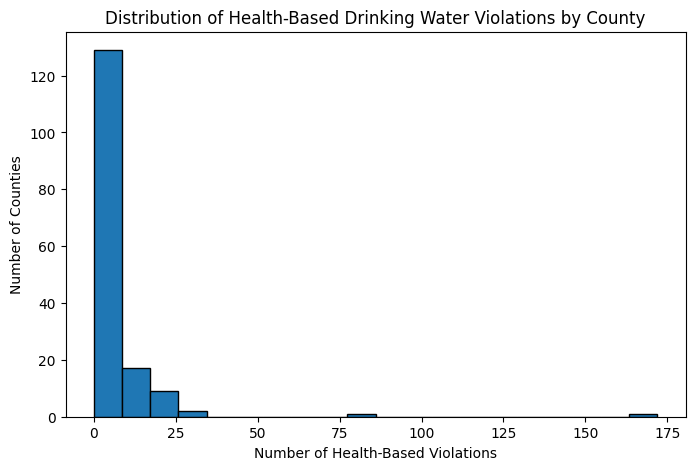

In [ ]:
# Distribution of health-based violations across Georgia counties
plt.figure(figsize=(8, 5))

plt.hist(
    analysis_df["health_violation_count"],
    bins=20,
    edgecolor="black"
)

plt.xlabel("Number of Health-Based Violations")
plt.ylabel("Number of Counties")
plt.title("Distribution of Health-Based Drinking Water Violations by County")

plt.show()

#### Distribution of Health-Based Violations

The number of health-based drinking water violations was strongly right-skewed. Most counties had relatively few violations, while a small number had much higher counts. Lowndes County had the highest count with 172 violations, followed by Warren County with 80. These high values were not removed because the records were already checked for duplicates and the violations occurred across multiple water systems.

The skewed distribution was taken into account when selecting the statistical methods for the analysis.

### Drinking Water Violations and Cancer Incidence

The relationship between the number of health-based drinking water violations and the age-adjusted cancer incidence rate was examined across Georgia counties. A scatterplot was first used to visualize the relationship between the two variables.

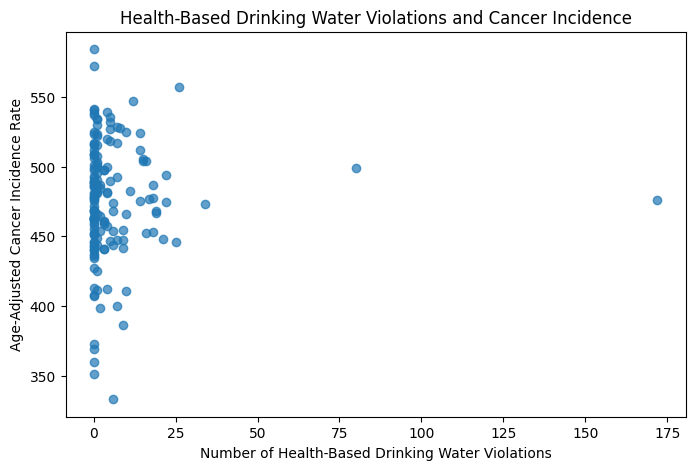

In [ ]:
# Scatterplot of health-based violations and cancer incidence
plt.figure(figsize=(8, 5))

plt.scatter(
    analysis_df["health_violation_count"],
    analysis_df["total_rate"],
    alpha=0.7
)

plt.xlabel("Number of Health-Based Drinking Water Violations")
plt.ylabel("Age-Adjusted Cancer Incidence Rate")
plt.title("Health-Based Drinking Water Violations and Cancer Incidence")

plt.show()

#### Correlation Analysis

The scatterplot did not show a clear relationship between the number of health-based drinking water violations and cancer incidence. The violation counts were also strongly right-skewed, with a few counties having much higher counts than the rest. Because of this, Spearman's rank correlation was used to examine the association between health-based violations and cancer incidence.

In [ ]:
from scipy.stats import spearmanr

# Spearman correlation between health-based violations
# and age-adjusted cancer incidence
spearman_r, spearman_p = spearmanr(
    analysis_df["health_violation_count"],
    analysis_df["total_rate"]
)

print(f"Spearman correlation: {spearman_r:.3f}")
print(f"P-value: {spearman_p:.4f}")

Spearman correlation: 0.071
P-value: 0.3765


#### Correlation Results

Spearman's rank correlation showed a very weak positive association between the number of health-based drinking water violations and the age-adjusted cancer incidence rate (ρ = 0.071, p = 0.3765). This association was not statistically significant.

Based on this preliminary analysis, there was no evidence of a meaningful association between the number of health-based drinking water violations and overall cancer incidence across Georgia counties. However, the violation count is only a county-level measure of potential exposure and does not measure the amount or duration of exposure experienced by individual residents.

In [ ]:
# Compare cancer incidence by health-based violation status
violation_group_summary = (
    analysis_df
    .groupby("any_health_violation")["total_rate"]
    .agg(["count", "mean", "median", "std", "min", "max"])
)

display(violation_group_summary)

,count,mean,median,std,min,max
any_health_violation,,,,,,
0,72,472.116667,470.2,43.977574,351.7,584.0
1,87,479.442529,481.9,39.751114,333.4,557.0


#### Cancer Incidence by Violation Status

Counties with at least one identified health-based drinking water violation had a mean age-adjusted cancer incidence rate of 479.4 per 100,000, compared with 472.1 per 100,000 among counties with no identified health-based violations. Median cancer incidence was also higher among counties with at least one violation (481.9 compared with 470.2 per 100,000).

These descriptive results show a small difference between the two groups, but a statistical test is needed to determine whether the difference is significant.

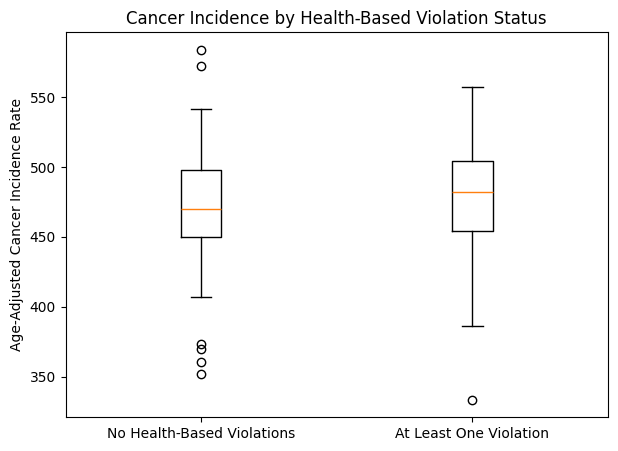

In [ ]:
# Compare cancer incidence distributions by violation status
no_violation = analysis_df[
    analysis_df["any_health_violation"] == 0
]["total_rate"]

violation = analysis_df[
    analysis_df["any_health_violation"] == 1
]["total_rate"]

plt.figure(figsize=(7, 5))

plt.boxplot(
    [no_violation, violation],
    tick_labels=[
        "No Health-Based Violations",
        "At Least One Violation"
    ]
)

plt.ylabel("Age-Adjusted Cancer Incidence Rate")
plt.title("Cancer Incidence by Health-Based Violation Status")

plt.show()

#### Comparing Counties With and Without Health-Based Violations

Cancer incidence rates were compared between counties with no identified health-based drinking water violations and counties with at least one violation. The distributions were visually examined using a boxplot. Because the two groups are independent and may have different variances, Welch's two-sample t-test was used to compare their mean cancer incidence rates.

In [ ]:
from scipy.stats import ttest_ind

# Welch's independent-samples t-test
t_stat, t_p = ttest_ind(
    no_violation,
    violation,
    equal_var=False
)

print(f"Welch's t-statistic: {t_stat:.3f}")
print(f"P-value: {t_p:.4f}")

# Difference in group means
mean_difference = violation.mean() - no_violation.mean()

print(f"Mean difference: {mean_difference:.2f} per 100,000")

Welch's t-statistic: -1.092
P-value: 0.2767
Mean difference: 7.33 per 100,000


#### Group Comparison Results

Counties with at least one identified health-based drinking water violation had an average cancer incidence rate 7.33 cases per 100,000 higher than counties with no identified health-based violations. However, Welch's t-test showed that this difference was not statistically significant (t = -1.092, p = 0.2767).

These results are consistent with the correlation analysis and do not show a statistically significant association between health-based drinking water violations and overall cancer incidence at the county level.

## Data Management Plan

The original cancer and EPA drinking water datasets will be kept in their original downloaded formats. The analysis notebook documents the data loading, cleaning, merging, and analysis steps so that the final dataset can be recreated from the original source files. The original source files will not be overwritten during the cleaning process.

The data used in this project are public datasets containing county-level cancer incidence information and public water system violation records. The analysis does not use individual-level identifying information, names, addresses, or other direct personal identifiers. Because the data are analyzed at the county level, privacy and security concerns related to individual health information are limited.

To support reproducibility, the notebook documents the data sources, variable selection, cleaning decisions, missing-value handling, duplicate checks, exposure-period definition, county-level data linkage, derived variables, and statistical analyses. The steps are organized sequentially so that the cleaned analysis dataset and results can be recreated from the original source data.